In [2]:
%cd ..

/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project


## Ausgabe relevanter Informationen
Die Funktion load_structure_info gibt alle relevanten Informationen zu einer Struktur (Input_ID) aus. Wahlweise können mit atom_positions = True auch die Atompositionen ausgegeben werden

In [3]:
from scripts.structures2 import load_by_entry_id

# Lädt die Struktur direkt anhand der OQMD Entry-ID aus der JSONL-Datei
#entry_id = 647362 # Beispiel aus deiner CaInBr3-Liste

def load_structure_info(entry_id, atom_positions = False):
  atoms = load_by_entry_id(entry_id)

  if atoms:
      # 1. Bandlücke (Band Gap) auslesen
      band_gap = atoms.info.get("band_gap", "Nicht verfügbar")
      
      # 2. Stabilität / Energie über der Elementarlinie (Energy above hull) auslesen
      # In OQMD-Datensätzen wird dies oft als "stability" bezeichnet
      energy_above_hull = atoms.info.get("stability", "Nicht verfügbar")
      
      # Zusätzliche nützliche OQMD-Metadaten
      spacegroup = atoms.info.get("spacegroup", "Nicht verfügbar")
      crystal_structure = atoms.info.get("cs", "Nicht verfügbar")
      delta_e = atoms.info.get("delta_e", "Nicht verfügbar") # Bildungsenergie
      name = atoms.info.get("name", "Nicht verfügbar")

      # Schöne Ausgabe printen
      print(f"--- Metadaten für OQMD Entry {entry_id} ---")
      print(f"Name:               {name}")
      print(f"System:             {atoms.get_chemical_formula()}")
      print(f"Raumgruppe:         {spacegroup}")
      print(f"Kristallstruktur:   {crystal_structure}")
      print(f"Bandlücke:          {band_gap} eV")
      print(f"Energy above Hull:  {energy_above_hull} eV/Atom")
      print(f"Bildungsenergie:    {delta_e} eV/Atom")
      print(f"Struktur: {atoms.get_chemical_formula()}")
      if atom_positions == True:
        print("Atompositionen (kartesisch):\n", atoms.get_positions())
      print("########################################################")

id_list = [1376747, 825272, 1428523, 6709, 6531]
for id in id_list:
  load_structure_info(id)

--- Metadaten für OQMD Entry 1376747 ---
Name:               NaSnBr3
System:             Br6Na2Sn2
Raumgruppe:         R3c
Kristallstruktur:   trigonal
Bandlücke:          2.259 eV
Energy above Hull:  0.0 eV/Atom
Bildungsenergie:    -1.33822124599007 eV/Atom
Struktur: Br6Na2Sn2
########################################################
--- Metadaten für OQMD Entry 825272 ---
Name:               AcAlO3
System:             Ac2Al2O6
Raumgruppe:         R-3c
Kristallstruktur:   trigonal
Bandlücke:          4.248 eV
Energy above Hull:  0.000998968000000211 eV/Atom
Bildungsenergie:    -3.53112525702725 eV/Atom
Struktur: Ac2Al2O6
########################################################
--- Metadaten für OQMD Entry 1428523 ---
Name:               TlCuBr3
System:             Br6Cu2Tl2
Raumgruppe:         Pm-3m
Kristallstruktur:   cubic
Bandlücke:          0.0 eV
Energy above Hull:  0.0357095041249994 eV/Atom
Bildungsenergie:    -0.694704178449502 eV/Atom
Struktur: Br6Cu2Tl2
######################

## Create SOAP Describtor

In [4]:
from dscribe.descriptors import SOAP
import numpy as np

# SOAP verlangt die Angabe aller Elemente, die im Modell vorkommen können
all_elements = ["Br", "Ca", "In"] 

# 2. SOAP-Generator konfigurieren
soap = SOAP(
    species=all_elements,
    periodic=True,         # Extrem wichtig, da es sich um ein Kristallgitter handelt!
    r_cut=6.0,             # Radius in Angström, der um jedes Atom herum gescannt wird
    n_max=4,               # Anzahl der radialen Basisfunktionen
    l_max=3,               # Maximale Ordnung der sphärischen Harmonischen (Winkelauflösung)
    average="outer",       # Mittelt die atomaren Umgebungen zu einem einzigen Vektor für das Material
    sparse=False
)

# 3. Invarianten SOAP-Vektor berechnen
entry_id = 647362
atoms = load_by_entry_id(entry_id)
soap_features = soap.create(atoms)

print("Form des SOAP-Vektors:", soap_features.shape)
# 1. Printe ersten 10 Zahlen des SOAP-Deskriptors
print("Erste 10 Zahlen des SOAP-Deskriptors:", soap_features[:10])

# 2. Überprüfe, ob der Vektor überhaupt Werte ungleich Null enthält
print("Gibt es Werte ungleich Null?", np.any(soap_features != 0))

# 3. Lass dir die Summe aller Werte ausgeben (wenn > 0, stecken Infos drin)
print("Summe des gesamten SOAP-Vektors:", np.sum(soap_features))



Form des SOAP-Vektors: (312,)
Erste 10 Zahlen des SOAP-Deskriptors: [ 0.05829434 -0.1615055   0.4558611  -1.01436057  2.77007993  1.35206879
  5.52523068  6.53207407 -5.27600515 27.81858937]
Gibt es Werte ungleich Null? True
Summe des gesamten SOAP-Vektors: 428.6357166552721


## Check SOAP Deskriptor
Überprüfe die Richtigkeit der SOAP Deskriptoren anhand einiger Beipiele und der berechneten Kernel-Matrix

Form des SOAP-Vektors: (6, 3960)


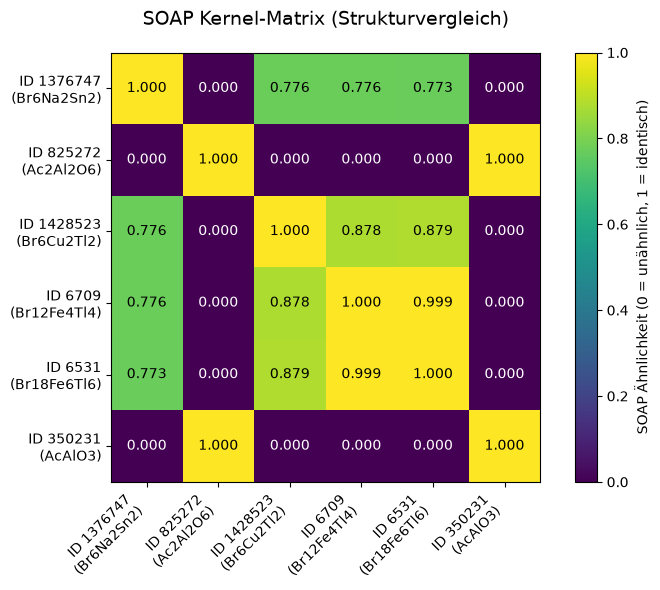

Numerische Kernel-Matrix:
 [[1.     0.     0.7756 0.7761 0.773  0.    ]
 [0.     1.     0.     0.     0.     1.    ]
 [0.7756 0.     1.     0.8782 0.8792 0.    ]
 [0.7761 0.     0.8782 1.     0.999  0.    ]
 [0.773  0.     0.8792 0.999  1.     0.    ]
 [0.     1.     0.     0.     0.     1.    ]]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dscribe.descriptors import SOAP
from scripts.structures import load_by_entry_id

# 1. Die gewünschten OQMD-Entry-IDs definieren
entry_ids = [1376747, 825272, 1428523, 6709, 6531,350231]

# Liste aller vorkommenden Elemente in DIESEN 5 Strukturen
# (Bitte anpassen, falls dort z.B. noch 'O', 'Cl', 'Cs' etc. enthalten sind!)
all_elements = ["Br", "Ca", "In", "Na", "Sn", "Tl", "Cu", "Fe", "Ac", "Al", "O"] 

# 2. Strukturen laden
valid_atoms = []
labels = []

for eid in entry_ids:
    atoms = load_by_entry_id(eid)
    if atoms:
        valid_atoms.append(atoms)
        # Erstellt ein Label aus ID und chemischer Formel für die Matrix-Achsen
        labels.append(f"ID {eid}\n({atoms.get_chemical_formula()})")
    else:
        print(f"Warnung: Struktur für ID {eid} konnte nicht geladen werden.")

# 3. SOAP-Generator konfigurieren (mit 'average="outer"')
soap = SOAP(
    species=all_elements,
    periodic=True,
    r_cut=6.0,
    n_max=4,
    l_max=3,
    average="outer",  # Kombiniert Atome zu einem einzigen Materialvektor
    sparse=False
)

# 4. SOAP-Features für alle 5 Strukturen berechnen
# Da wir eine Liste von Atoms übergeben, erhalten wir eine 2D-Matrix (5, 96)
soap_vectors = soap.create(valid_atoms)
print("Form des SOAP-Vektors:", soap_vectors.shape)

# 5. SOAP-Vektoren normalisieren (wichtig für den korrekten Ähnlichkeitsvergleich)
# Ein normalisierter Vektor hat die Länge (Norm) 1
row_norms = np.linalg.norm(soap_vectors, axis=1, keepdims=True)
soap_vectors_normalized = soap_vectors / row_norms

# 6. Kernel-Matrix (Ähnlichkeitsmatrix) berechnen
# Das Skalarprodukt (Dot Product) der normalisierten Vektoren ergibt die Kosinus-Ähnlichkeit
kernel_matrix = np.dot(soap_vectors_normalized, soap_vectors_normalized.T)

# 7. Die Kernel-Matrix visuell darstellen
plt.figure(figsize=(8, 6))
# 'viridis' oder 'plasma' eignen sich gut. vmin/vmax fixieren die Skala von 0 bis 1
cax = plt.imshow(kernel_matrix, cmap='viridis', vmin=0.0, vmax=1.0) 
plt.colorbar(cax, label="SOAP Ähnlichkeit (0 = unähnlich, 1 = identisch)")

# Achsen beschriften
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)

# Werte direkt in die Quadrate schreiben
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{kernel_matrix[i, j]:.3f}", 
                 ha="center", va="center", 
                 color="white" if kernel_matrix[i, j] < 0.6 else "black")

plt.title("SOAP Kernel-Matrix (Strukturvergleich)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Optional: Numerische Matrix in der Konsole ausgeben
print("Numerische Kernel-Matrix:\n", np.round(kernel_matrix, 4))

## Extrahieren aller chemischen Elemente
Erstellt eine Liste mit allen chemischen Elementen. Notwendig für ASE, DScribe

In [6]:
import pandas as pd
from scripts.structures2 import load_by_entry_id

def extract_all_elements_from_csv(csv_path):
    """
    Liest die entry_ids aus der zweiten Spalte einer CSV-Datei und
    extrahiert eine eindeutige Liste aller vorkommenden chemischen Elemente.
    """
    # 1. Nur die zweite Spalte (Index 1) aus der CSV laden
    # iloc[:, 1] sorgt dafür, dass wir die zweite Spalte erwischen, egal wie sie heißt
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()
    
    print(f"Erfolgreich {len(id_list)} IDs aus '{csv_path}' geladen.")
    
    # 2. Set für eindeutige Elemente vorbereiten
    unique_elements = set()
    
    print("Scanne alle Strukturen nach chemischen Elementen (dies kann bei vielen Einträgen kurz dauern)...")
    
    # Zähler für nicht gefundene IDs (zur Absicherung)
    missing_count = 0
    
    for i, entry_id in enumerate(id_list):
        try:
            atoms = load_by_entry_id(entry_id)
            if atoms:
                symbols = atoms.get_chemical_symbols()
                unique_elements.update(symbols)
        except (KeyError, FileNotFoundError):
            # Falls eine ID mal nicht im jsonl-Cache existiert, überspringen wir sie
            missing_count += 1
            continue
            
        # Kleines Fortschritts-Update bei großen Datensätzen
        if (i + 1) % 500 == 0:
            print(f"-> {i + 1} / {len(id_list)} IDs verarbeitet...")
            
    # 3. Das Set in eine sortierte Liste umwandeln
    all_elements_list = sorted(list(unique_elements))
    
    print("\n=== SCAN ABGESCHLOSSEN ===")
    print(f"Verarbeitete Strukturen: {len(id_list) - missing_count}")
    if missing_count > 0:
        print(f"Warnung: {missing_count} IDs wurden nicht im Struktur-Cache gefunden.")
    print(f"Gefundene Elemente ({len(all_elements_list)}): {all_elements_list}")
    
    return all_elements_list

# ==========================================
# ANWENDUNGSBEISPIEL in deinem Notebook:
# ==========================================

# Pfad zu deiner CSV-Datei
csv_file_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"

# Funktion ausführen
global_species_list = extract_all_elements_from_csv(csv_file_path)

# Jetzt hast du die perfekte Liste für deinen SOAP-Deskriptor:
# soap = SOAP(species=global_species_list, periodic=True, ...)

Erfolgreich 16323 IDs aus '/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv' geladen.
Scanne alle Strukturen nach chemischen Elementen (dies kann bei vielen Einträgen kurz dauern)...
-> 500 / 16323 IDs verarbeitet...
-> 1000 / 16323 IDs verarbeitet...
-> 1500 / 16323 IDs verarbeitet...
-> 2000 / 16323 IDs verarbeitet...
-> 2500 / 16323 IDs verarbeitet...
-> 3000 / 16323 IDs verarbeitet...
-> 3500 / 16323 IDs verarbeitet...
-> 4000 / 16323 IDs verarbeitet...
-> 4500 / 16323 IDs verarbeitet...
-> 5000 / 16323 IDs verarbeitet...
-> 5500 / 16323 IDs verarbeitet...
-> 6000 / 16323 IDs verarbeitet...
-> 6500 / 16323 IDs verarbeitet...
-> 7000 / 16323 IDs verarbeitet...
-> 7500 / 16323 IDs verarbeitet...
-> 8000 / 16323 IDs verarbeitet...
-> 8500 / 16323 IDs verarbeitet...
-> 9000 / 16323 IDs verarbeitet...
-> 9500 / 16323 IDs verarbeitet...
-> 10000 / 16323 IDs verarbeitet...
-> 10500 / 16323 IDs verarbeitet...
-> 11000 / 16323 IDs ve

In [7]:
# Gefundene Elemente (84): ['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'O', 'Os', 'P', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']

import json
# Als Textdatei im JSON-Format abspeichern
with open("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/structures/global_species_list.txt", "w") as f:
    json.dump(global_species_list, f)

print("Elementliste erfolgreich in 'global_species_list.txt' gespeichert!")

Elementliste erfolgreich in 'global_species_list.txt' gespeichert!


In [8]:
import json

with open("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/structures/global_species_list.txt", "r") as f:
    loaded_species = json.load(f)

print("Liste erfolgreich geladen:", loaded_species)
# Jetzt direkt nutzen:
# soap = SOAP(species=loaded_species, periodic=True, ...)

Liste erfolgreich geladen: ['Ac', 'Ag', 'Al', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'O', 'Os', 'P', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Y', 'Yb', 'Zn', 'Zr']


### Häufigkeit der vorkommenden Elemente

Erfolgreich 16323 IDs geladen.
Scanne alle Strukturen und zähle die Atomsorten...
-> 1000 / 16323 Strukturen gescannt...
-> 2000 / 16323 Strukturen gescannt...
-> 3000 / 16323 Strukturen gescannt...
-> 4000 / 16323 Strukturen gescannt...
-> 5000 / 16323 Strukturen gescannt...
-> 6000 / 16323 Strukturen gescannt...
-> 7000 / 16323 Strukturen gescannt...
-> 8000 / 16323 Strukturen gescannt...
-> 9000 / 16323 Strukturen gescannt...
-> 10000 / 16323 Strukturen gescannt...
-> 11000 / 16323 Strukturen gescannt...
-> 12000 / 16323 Strukturen gescannt...
-> 13000 / 16323 Strukturen gescannt...
-> 14000 / 16323 Strukturen gescannt...
-> 15000 / 16323 Strukturen gescannt...
-> 16000 / 16323 Strukturen gescannt...

=== SCAN BEENDET ===


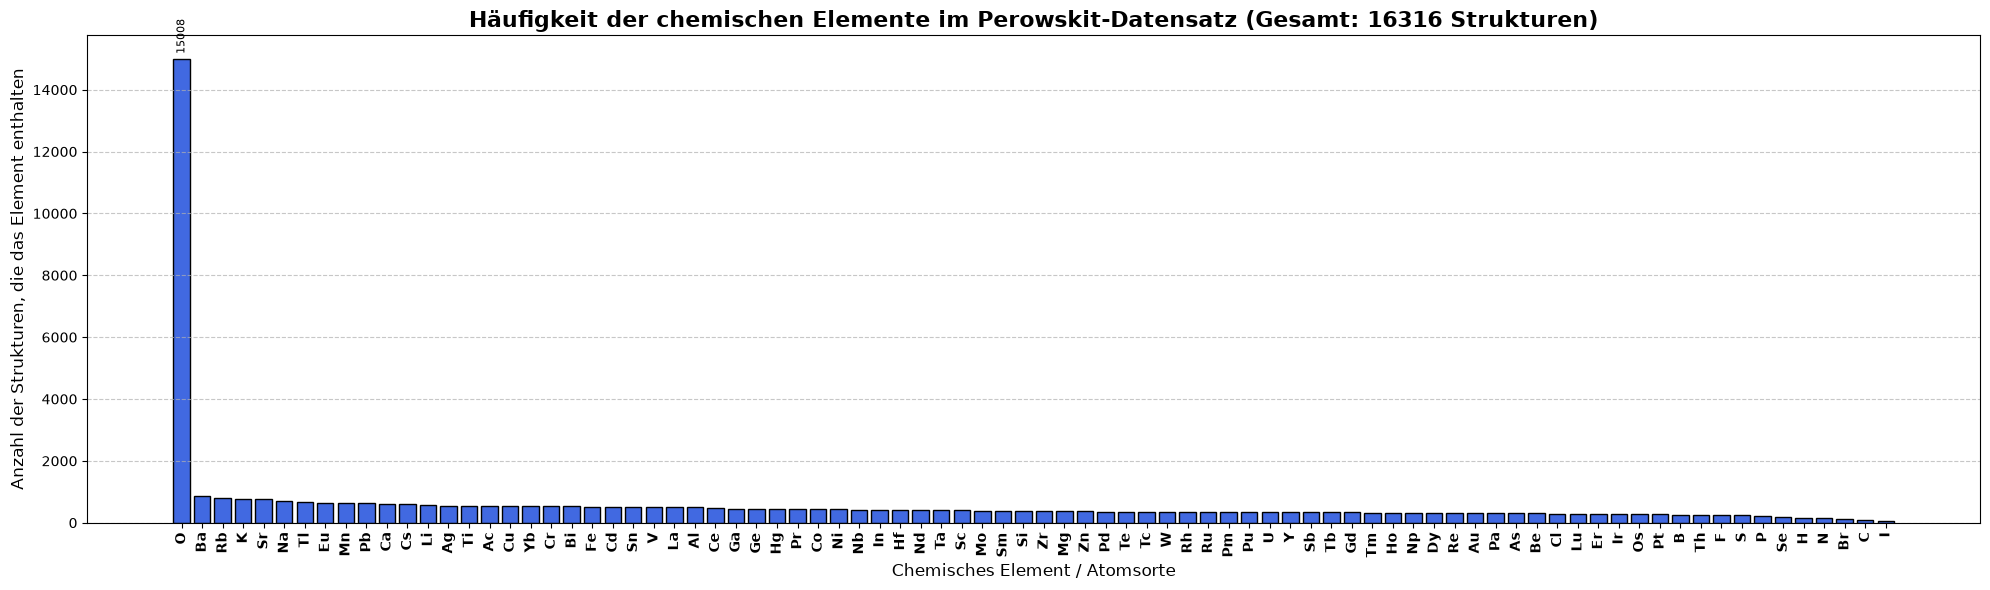

In [11]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from scripts.structures2 import load_by_entry_id


def count_and_plot_elements(csv_path):
    """Liest die entry_ids aus einer CSV, zählt das Vorkommen jedes Elements

    pro Struktur und plottet das Ergebnis.
    """
    # 1. IDs aus der zweiten Spalte laden
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()

    print(f"Erfolgreich {len(id_list)} IDs geladen.")

    # Ein Counter zählt automatisch, wie oft ein Element vorkommt
    element_counts = Counter()
    missing_count = 0

    print("Scanne alle Strukturen und zähle die Atomsorten...")

    for i, entry_id in enumerate(id_list):
        try:
            atoms = load_by_entry_id(entry_id)
            if atoms:
                # set(atoms.get_chemical_symbols()) sorgt dafür, dass wir jedes Element
                # pro Kristallstruktur nur MAXIMAL EINMAL zählen (egal ob ABX3 3x X hat)
                unique_in_structure = set(atoms.get_chemical_symbols())

                # Counter aktualisieren
                element_counts.update(unique_in_structure)

        except (KeyError, FileNotFoundError):
            missing_count += 1
            continue

        if (i + 1) % 1000 == 0:
            print(f"-> {i + 1} / {len(id_list)} Strukturen gescannt...")

    print("\n=== SCAN BEENDET ===")

    # 2. Daten für den Plot vorbereiten (nach Häufigkeit sortieren)
    # .most_common() sortiert automatisch vom häufigsten zum seltensten Element
    sorted_elements_data = element_counts.most_common()
    elements, counts = zip(*sorted_elements_data)

    # 3. Das Diagramm plotten
    # Da es 84 Elemente sind, machen wir den Plot schön breit (20 Zoll)
    plt.figure(figsize=(20, 6))

    # Balken erstellen (mit einer schicken blauen Farbe)
    bars = plt.bar(elements, counts, color="royalblue", edgecolor="black")

    # Diagramm-Styling
    plt.title(
        f"Häufigkeit der chemischen Elemente im Perowskit-Datensatz (Gesamt: {len(id_list) - missing_count} Strukturen)",
        fontsize=16,
        fontweight="bold",
    )
    plt.xlabel("Chemisches Element / Atomsorte", fontsize=12)
    plt.ylabel("Anzahl der Strukturen, die das Element enthalten", fontsize=12)
    plt.xticks(
        rotation=90, fontsize=10, fontweight="bold"
    )  # Dreht die Elementsymbole um 90 Grad
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Optionale Spielerei: Die exakte Zahl über die Top-Balken schreiben
    # (Damit es bei 84 Elementen nicht zu voll wird, nur für Balken mit signifikanten Werten)
    for bar in bars:
        yval = bar.get_height()
        if (
            yval > max(counts) * 0.1
        ):  # Nur anzeigen, wenn der Balken größer als 10% des Maximums ist
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                yval + (max(counts) * 0.01),
                f"{int(yval)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

    plt.tight_layout()
    plt.show()

    # Gibt das fertige Dictionary zurück, falls du die Zahlen als Text brauchst
    return dict(sorted_elements_data)


# ==========================================
# AUSFÜHRUNG in deinem Notebook:
# ==========================================
csv_file_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"

# Funktion starten (Zählt alles und zeigt sofort den Plot an)
element_statistics = count_and_plot_elements(csv_file_path)

### Häufigkeit der Elemente auf den jeweiligen Kristallpositionen

Erfolgreich 16323 IDs geladen. Starte Positions-Analyse...
-> 2000 / 16323 Strukturen gescannt...
-> 4000 / 16323 Strukturen gescannt...
-> 6000 / 16323 Strukturen gescannt...
-> 8000 / 16323 Strukturen gescannt...
-> 10000 / 16323 Strukturen gescannt...
-> 12000 / 16323 Strukturen gescannt...
-> 14000 / 16323 Strukturen gescannt...
-> 16000 / 16323 Strukturen gescannt...

=== SCAN BEENDET ===
Erfolgreich zugeordnet: 16316 Strukturen


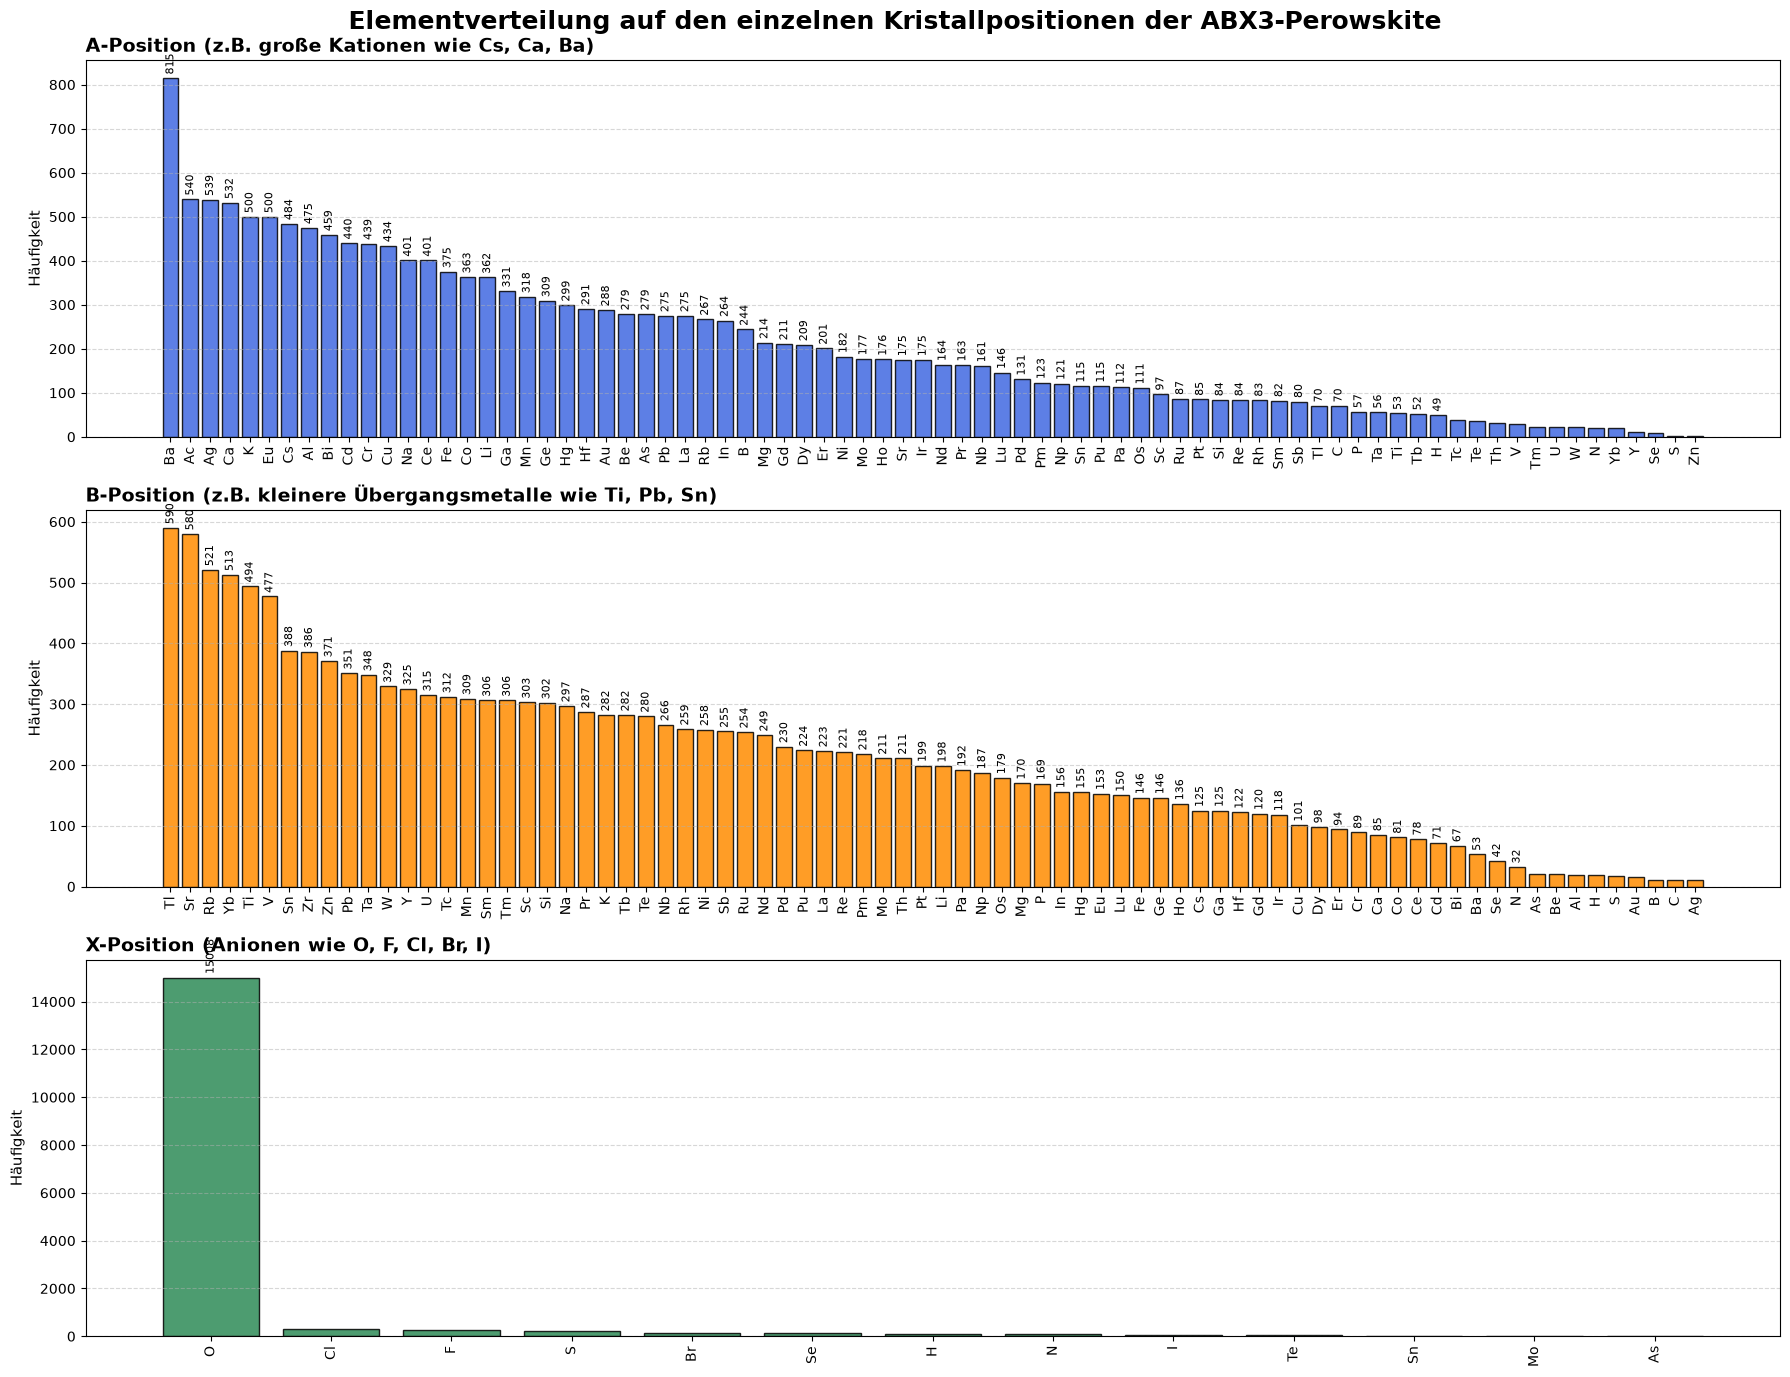

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scripts.structures2 import load_by_entry_id

def count_and_plot_perovskite_positions(csv_path):
    """
    Analysiert Perowskit-Strukturen und ordnet Elemente den Positionen A, B und X zu.
    Erstellt anschließend drei getrennte Histogramme.
    """
    # 1. IDs laden
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()

    print(f"Erfolgreich {len(id_list)} IDs geladen. Starte Positions-Analyse...")

    # Drei separate Counter für A, B und X
    counts_A = Counter()
    counts_B = Counter()
    counts_X = Counter()
    
    missing_count = 0
    error_count = 0

    for i, entry_id in enumerate(id_list):
        try:
            atoms = load_by_entry_id(entry_id)
            if not atoms:
                missing_count += 1
                continue
            
            # Chemische Symbole und deren exakte Anzahl in dieser Struktur holen
            symbols = atoms.get_chemical_symbols()
            sym_counts = Counter(symbols)
            
            # Sortiere die Elemente nach ihrer Häufigkeit in DIESER Struktur (aufsteigend)
            # Bei ABX3 erwarten wir ein Verhältnis von z.B. 1 : 1 : 3 oder 2 : 2 : 6
            unique_elements_sorted = [item[0] for item in sym_counts.most_common()] # Meistgehasstes ist hinten
            
            # Falls die Struktur nicht die typischen 3 unterschiedlichen Elemente hat,
            # weichen wir auf die Standardreihenfolge der Formel aus
            if len(unique_elements_sorted) != 3:
                # Versuche aus der Formel (z.B. CaTiO3) die 3 Elemente zu ziehen
                # Falls das fehlschlägt, überspringen wir die Zuordnung für diese eine Struktur
                error_count += 1
                continue
                
            # Zuordnung nach typischer ABX3-Stöchiometrie:
            # Das Element mit der HÖCHSTEN Anzahl (most_common[0]) ist die X-Position (Anion)
            elem_X = sym_counts.most_common(1)[0][0]
            
            # Die verbleibenden zwei Elemente sind A und B. 
            # In der Regel liefert atoms.get_chemical_symbols() sie in der Reihenfolge A, dann B.
            # Wir filtern X heraus und behalten die ursprüngliche relative Reihenfolge bei:
            remaining = [s for s in unique_elements_sorted if s != elem_X]
            
            if len(remaining) == 2:
                elem_A = remaining[0]
                elem_B = remaining[1]
                
                # Counter hochzählen (jede Struktur zählt 1x pro Position)
                counts_A.update([elem_A])
                counts_B.update([elem_B])
                counts_X.update([elem_X])

        except Exception as e:
            missing_count += 1
            continue

        if (i + 1) % 2000 == 0:
            print(f"-> {i + 1} / {len(id_list)} Strukturen gescannt...")

    print("\n=== SCAN BEENDET ===")
    print(f"Erfolgreich zugeordnet: {len(id_list) - missing_count - error_count} Strukturen")
    if error_count > 0:
        print(f"Hinweis: {error_count} Strukturen übersprungen (keine exakt 3 unterschiedlichen Elemente).")

    # ==========================================
    # 2. PLOTTING: Drei Histogramme untereinander
    # ==========================================
    fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharey=False)
    
    positions_data = [
        ("A-Position (z.B. große Kationen wie Cs, Ca, Ba)", counts_A, "royalblue"),
        ("B-Position (z.B. kleinere Übergangsmetalle wie Ti, Pb, Sn)", counts_B, "darkorange"),
        ("X-Position (Anionen wie O, F, Cl, Br, I)", counts_X, "seagreen")
    ]
    
    for ax, (title, counter_data, color) in zip(axes, positions_data):
        if not counter_data:
            ax.set_title(f"Keine Daten für {title}")
            continue
            
        # Daten sortieren
        sorted_data = counter_data.most_common()
        elements, counts = zip(*sorted_data)
        
        # Bars plotten
        bars = ax.bar(elements, counts, color=color, edgecolor="black", alpha=0.85)
        
        # Styling pro Achse
        ax.set_title(title, fontsize=14, fontweight="bold", loc="left")
        ax.set_ylabel("Häufigkeit", fontsize=11)
        ax.tick_params(axis='x', rotation=90, labelsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        
        # Zahlen über die Top-Balken schreiben
        max_val = max(counts)
        for bar in bars:
            yval = bar.get_height()
            if yval > max_val * 0.05: # Nur anzeigen, wenn Balken > 5% vom Maximum ist
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    yval + (max_val * 0.01),
                    f"{int(yval)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90
                )

    # Gesamttitel und Layout optimieren
    plt.suptitle("Elementverteilung auf den einzelnen Kristallpositionen der ABX3-Perowskite", 
                 fontsize=18, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

# Run
csv_file_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"
count_and_plot_perovskite_positions(csv_file_path)

## Anzahl an Atomen in der Einheitszelle

Lese Atomanzahl für 16323 Strukturen aus... (Das geht sehr schnell)
-> 2000 / 16323 Strukturen gescannt...
-> 4000 / 16323 Strukturen gescannt...
-> 6000 / 16323 Strukturen gescannt...
-> 8000 / 16323 Strukturen gescannt...
-> 10000 / 16323 Strukturen gescannt...
-> 12000 / 16323 Strukturen gescannt...
-> 14000 / 16323 Strukturen gescannt...
-> 16000 / 16323 Strukturen gescannt...

=== ANALYSE BEENDET ===
Kleinste Atomanzahl im Datensatz: 5
Größte Atomanzahl im Datensatz:  80 <--- Das ist dein perfektes 'n_atoms_max'!
Fehlende Strukturen (nicht im Cache): 7


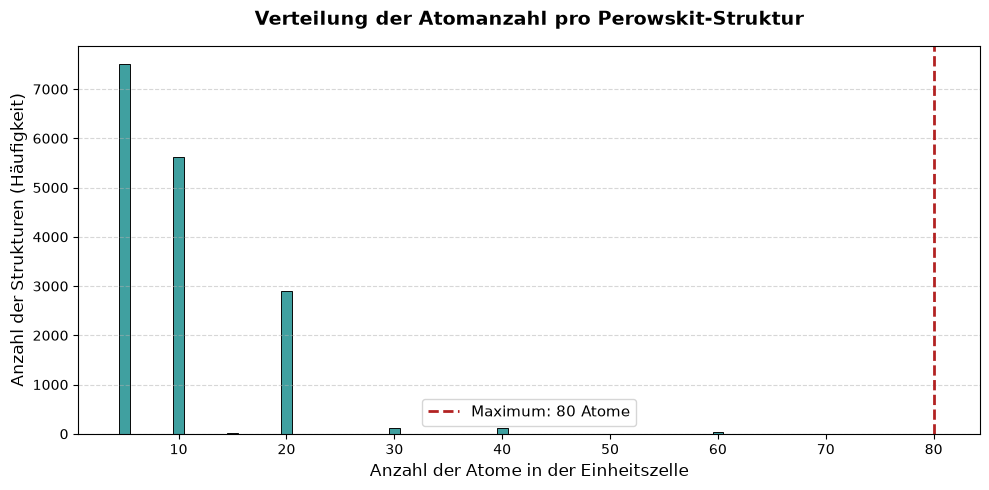

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scripts.structures2 import load_by_entry_id

def analyze_atom_counts():
    # 1. IDs aus der CSV einlesen
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()

    print(f"Lese Atomanzahl für {len(id_list)} Strukturen aus...")
    
    atom_counts = []
    missing_ids = []

    # Schneller Durchlauf nur zum Zählen
    for i, idx in enumerate(id_list):
        try:
            atoms = load_by_entry_id(idx)
            if atoms:
                atom_counts.append(len(atoms))
            else:
                missing_ids.append(idx)
        except (KeyError, FileNotFoundError):
            missing_ids.append(idx)
            continue
            
        if (i + 1) % 2000 == 0:
            print(f"-> {i + 1} / {len(id_list)} Strukturen gescannt...")

    # Statistiken berechnen
    max_atoms = max(atom_counts) if atom_counts else 0
    min_atoms = min(atom_counts) if atom_counts else 0
    
    print("\n=== ANALYSE BEENDET ===")
    print(f"Kleinste Atomanzahl im Datensatz: {min_atoms}")
    print(f"Größte Atomanzahl im Datensatz:  {max_atoms} <--- Das ist dein perfektes 'n_atoms_max'!")
    print(f"Fehlende Strukturen (nicht im Cache): {len(missing_ids)}")

    # 2. Histogramm plotten
    plt.figure(figsize=(10, 5))
    
    # Da Atomanzahlen diskret (ganze Zahlen) sind, nutzen wir diskrete Bins
    sns.histplot(atom_counts, kde=False, color="teal", edgecolor="black", discrete=True)
    
    plt.title("Verteilung der Atomanzahl pro Perowskit-Struktur", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Anzahl der Atome in der Einheitszelle", fontsize=12)
    plt.ylabel("Anzahl der Strukturen (Häufigkeit)", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    
    # Zeige die wichtigsten Werte direkt im Plot an
    plt.axvline(max_atoms, color="firebrick", linestyle="--", linewidth=2, label=f"Maximum: {max_atoms} Atome")
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Funktion starten
analyze_atom_counts()

## Feature Engineering
Erstelle neue .csv Datei mit allen relevanten Einträgen, aber ohne lange SOAP Deskriptor. Hilfreich um Strukturen bzw. Werte nachzuschlagen.
Erstelle außerdem eine .npy Dateil aller Strukturen mit SOAP Deskriptor um effizient Modelle zu trainieren.

In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from dscribe.descriptors import SOAP
from scripts.structures2 import load_by_entry_id

def update_dateset(include_soap = True):
    # 0. Gespeicherte Elementliste laden (JSON-Weg aus dem vorherigen Schritt)
    # Passe den Pfad an, falls die Datei in einem anderen Ordner liegt
    with open("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/structures/global_species_list.txt", "r") as f:
        loaded_species = json.load(f)

    # 1. SOAP-Generator konfigurieren
    all_elements = loaded_species
    soap = SOAP(
        species=all_elements,
        periodic=True,
        r_cut=6.0,
        n_max=3,
        l_max=2,
        average="outer",
        sparse=False
    )

    # 2. Listen für die getrennten Daten vorbereiten
    metadata_rows = []
    soap_vectors_list = []

    # Datensatz einlesen und IDs extrahieren
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()

    print(f"Starte Feature-Engineering für {len(id_list)} Strukturen...")

    missing_count = 0

    # Hauptschleife über alle IDs
    for i, idx in enumerate(id_list):
        try:
            atoms = load_by_entry_id(idx)
            if not atoms:
                continue

            # Bandlücke und Stabilität auslesen
            bg_value = atoms.info.get("band_gap", np.nan)
            hull_value = atoms.info.get("stability", np.nan)
                
            # A. Reine Metadaten extrahieren (ohne SOAP!)
            meta = {
                "entry_id": idx,
                "name": atoms.info.get("name", np.nan),
                "formula": atoms.get_chemical_formula(),
                "spacegroup": atoms.info.get("spacegroup", np.nan),
                "crystal_structure": atoms.info.get("cs", np.nan),
                "band_gap": atoms.info.get("band_gap", np.nan),
                "is_metal": True if bg_value == 0.0 else False,
                "energy_above_hull": atoms.info.get("stability", np.nan),
                "is_stable": True if hull_value == 0.0 else False,
                "delta_e": atoms.info.get("delta_e", np.nan)
            }
            metadata_rows.append(meta)
            
            if include_soap == True:
                # B. SOAP-Vektor berechnen und separat merken
                soap_vector = soap.create(atoms)
                soap_vectors_list.append(soap_vector)
            
        except (KeyError, FileNotFoundError):
            # Falls eine ID mal nicht im jsonl-Cache existiert, überspringen wir sie sauber
            missing_count += 1
            continue

        # Kleines Fortschritts-Update bei großen Datensätzen
        if (i + 1) % 500 == 0:
            print(f"-> {i + 1} / {len(id_list)} IDs verarbeitet...")

    print("\n=== BERECHNUNG ABGESCHLOSSEN ===")
    print(f"Erfolgreich verarbeitete Strukturen: {len(id_list) - missing_count}")
    if missing_count > 0:
        print(f"Warnung: {missing_count} IDs wurden nicht im Struktur-Cache gefunden und übersprungen.")

    # 3. Metadaten in einen DataFrame umwandeln und als saubere CSV speichern
    df_metadata = pd.DataFrame(metadata_rows)
    df_metadata.to_csv("perovskite_metadata_overview.csv", index=False)
    print("✓ Übersichtliche CSV-Datei 'perovskite_metadata_overview.csv' wurde gespeichert.")

    # 4. SOAP-Vektoren in eine hocheffiziente, binäre Numpy-Matrix umwandeln
    if include_soap == True:
        soap_matrix = np.array(soap_vectors_list)
        np.save("perovskite_soap_features.npy", soap_matrix)
        print(f"✓ Effiziente SOAP-Feature-Matrix gespeichert. Form: {soap_matrix.shape}")

In [10]:
update_dateset(include_soap=True)

Starte Feature-Engineering für 16323 Strukturen...
-> 500 / 16323 IDs verarbeitet...
-> 1000 / 16323 IDs verarbeitet...
-> 1500 / 16323 IDs verarbeitet...
-> 2000 / 16323 IDs verarbeitet...
-> 2500 / 16323 IDs verarbeitet...
-> 3000 / 16323 IDs verarbeitet...
-> 3500 / 16323 IDs verarbeitet...
-> 4000 / 16323 IDs verarbeitet...
-> 4500 / 16323 IDs verarbeitet...
-> 5000 / 16323 IDs verarbeitet...
-> 5500 / 16323 IDs verarbeitet...
-> 6000 / 16323 IDs verarbeitet...
-> 6500 / 16323 IDs verarbeitet...
-> 7000 / 16323 IDs verarbeitet...
-> 7500 / 16323 IDs verarbeitet...
-> 8000 / 16323 IDs verarbeitet...
-> 8500 / 16323 IDs verarbeitet...
-> 9000 / 16323 IDs verarbeitet...
-> 9500 / 16323 IDs verarbeitet...
-> 10000 / 16323 IDs verarbeitet...
-> 10500 / 16323 IDs verarbeitet...
-> 11000 / 16323 IDs verarbeitet...
-> 11500 / 16323 IDs verarbeitet...
-> 12000 / 16323 IDs verarbeitet...
-> 12500 / 16323 IDs verarbeitet...
-> 13000 / 16323 IDs verarbeitet...
-> 13500 / 16323 IDs verarbeitet.

## Reduced Dataset
Datenset ohne Strukturen, die radioaktive Materialien oder seltene Erden enthalten

In [18]:
import pandas as pd
from scripts.structures2 import load_by_entry_id

# 1. Die bereinigte Elementliste definieren (keine seltenen Erden / Radioaktiven)
clean_species_list = [
    "Ag", "Al", "As", "Au", "B", "Ba", "Be", "Bi", "Br", "C", "Ca", "Cd", "Cl", 
    "Co", "Cr", "Cs", "Cu", "F", "Fe", "Ga", "Ge", "H", "Hf", "Hg", "I", "In", 
    "Ir", "K", "Mg", "Mn", "Mo", "N", "Na", "Nb", "Ni", "O", "Os", "P", "Pb", 
    "Pd", "Pt", "Rb", "Re", "Rh", "Ru", "S", "Sb", "Sc", "Se", "Si", "Sn", "Sr", 
    "Ta", "Ti", "Tl", "V", "W", "Y", "Zn", "Zr"
]
# Wir machen ein Set daraus, da die Abfrage "is in" bei Sets blitzschnell ist

‚
def create_reduced_datase(clean_species_list, include_soap=True):
    clean_species_set = set(clean_species_list)

    # 1. Define SOAP
    all_elements = clean_species_list
    soap = SOAP(
        species=all_elements,
        periodic=True,
        r_cut=6.0,
        n_max=3,
        l_max=2,
        average="outer",
        sparse=False
    )

    # 2. Original-CSV laden
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview.csv"
    df_original = pd.read_csv(csv_path)

    print(f"Originaler Datensatz enthält {len(df_original)} Zeilen.")
    print("Starte Filterung der Strukturen anhand der erlaubten Elemente...")

    # Liste für die Zeilen, die den Filter bestehen
    filtered_rows = []
    soap_vectors_list = []
    missing_count = 0

    # Wir loopen über den DataFrame (Zeile für Zeile)
    for i, row in df_original.iterrows():
        # Die entry_id steht in der zweiten Spalte (Spaltenindex 1)
        entry_id = int(row.iloc[0])
        
        try:
            atoms = load_by_entry_id(entry_id)
            if atoms:
                # Alle in DIESER Struktur vorkommenden Elemente ermitteln
                structure_elements = set(atoms.get_chemical_symbols())
                
                # PRÜFUNG: Ist die Struktur eine Teilmenge unserer erlaubten Elemente?
                # .issubset() gibt True zurück, wenn ALLE Atome in clean_species_set enthalten sind
                if structure_elements.issubset(clean_species_set):
                    filtered_rows.append(row)
                
                    if include_soap == True:
                        # B. SOAP-Vektor berechnen und separat merken
                        soap_vector = soap.create(atoms)
                        soap_vectors_list.append(soap_vector)
                    
        except (KeyError, FileNotFoundError):
            missing_count += 1
            continue

        # Kleines Fortschritts-Update
        if (i + 1) % 1000 == 0:
            print(f"-> {i + 1} / {len(df_original)} Strukturen überprüft. Aktuell {len(filtered_rows)} Treffer...")

    print("\n=== FILTERUNG BEENDET ===")
    print(f"Nicht im Cache gefundene IDs: {missing_count}")

    # 3. Neuen DataFrame aus den gefilterten Zeilen erstellen
    df_filtered = pd.DataFrame(filtered_rows)

    print(f"Neuer gefilterter Datensatz enthält {len(df_filtered)} Strukturen.")

    # 4. Als neues Dataset abspeichern
    output_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced.csv"
    df_filtered.to_csv(output_path, index=False)

    print(f"✓ Erfolgreich neues Dataset gespeichert unter: {output_path}")

    # 4. SOAP-Vektoren in eine hocheffiziente, binäre Numpy-Matrix umwandeln
    if include_soap == True:
        soap_matrix = np.array(soap_vectors_list)
        np.save("/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_soap_features_reduced.npy", soap_matrix)
        print(f"✓ Effiziente SOAP-Feature-Matrix gespeichert. Form: {soap_matrix.shape}")

In [19]:
create_reduced_datase(clean_species_list, include_soap=True)

Originaler Datensatz enthält 16316 Zeilen.
Starte Filterung der Strukturen anhand der erlaubten Elemente...
-> 1000 / 16316 Strukturen überprüft. Aktuell 753 Treffer...
-> 2000 / 16316 Strukturen überprüft. Aktuell 1258 Treffer...
-> 3000 / 16316 Strukturen überprüft. Aktuell 2019 Treffer...
-> 4000 / 16316 Strukturen überprüft. Aktuell 2564 Treffer...
-> 5000 / 16316 Strukturen überprüft. Aktuell 2962 Treffer...
-> 6000 / 16316 Strukturen überprüft. Aktuell 3247 Treffer...
-> 7000 / 16316 Strukturen überprüft. Aktuell 3876 Treffer...
-> 8000 / 16316 Strukturen überprüft. Aktuell 4037 Treffer...
-> 9000 / 16316 Strukturen überprüft. Aktuell 4612 Treffer...
-> 10000 / 16316 Strukturen überprüft. Aktuell 5151 Treffer...
-> 11000 / 16316 Strukturen überprüft. Aktuell 5217 Treffer...
-> 12000 / 16316 Strukturen überprüft. Aktuell 5716 Treffer...
-> 13000 / 16316 Strukturen überprüft. Aktuell 6300 Treffer...
-> 14000 / 16316 Strukturen überprüft. Aktuell 6714 Treffer...
-> 15000 / 16316 Str

# ==============================================================

## Create Coulomb Matrices

In [9]:
import numpy as np
import pandas as pd
from dscribe.descriptors import CoulombMatrix
from scripts.structures2 import load_by_entry_id

# 1. Definiere 5 Beispiel-IDs (Ersetze diese mit IDs aus deinem Datensatz)
beispiel_ids = [1376747, 825272, 1428523, 6709, 6531,350231]

# 2. Strukturen vorab laden und die maximale Atomanzahl bestimmen
geladene_strukturen = {}
max_atoms = 0

print("Lade Strukturen und ermittle maximale Atomanzahl...")
for idx in beispiel_ids:
    atoms = load_by_entry_id(idx)
    if atoms is not None:
        geladene_strukturen[idx] = atoms
        print(f"-> ID {idx} geladen: {atoms.get_chemical_formula()} ({len(atoms)} Atome)")
        if len(atoms) > max_atoms:
            max_atoms = len(atoms)
    else:
        print(f"❌ ID {idx} konnte nicht geladen werden.")

# 3. Den Coulomb-Matrix-Generator mit der maximalen Atomanzahl konfigurieren
# flatten=True ist standardmäßig aktiv, wenn man es nicht explizit ausschaltet.
cm_ml_generator = CoulombMatrix(
    n_atoms_max=max_atoms,
    permutation="sorted_l2",  # Wichtig für den Strukturvergleich
    sparse=False
)

# 4. Coulomb-Vektoren berechnen und in einem Dictionary speichern
coulomb_vektoren = {}
for idx, atoms in geladene_strukturen.items():
    coulomb_vektoren[idx] = cm_ml_generator.create(atoms)

print(f"\n✓ Coulomb-Vektoren für {len(coulomb_vektoren)} Strukturen berechnet.")
print(f"Jeder Vektor hat eine einheitliche Länge von: {max_atoms * max_atoms} Features.")

Lade Strukturen und ermittle maximale Atomanzahl...
-> ID 1376747 geladen: Br6Na2Sn2 (10 Atome)
-> ID 825272 geladen: Ac2Al2O6 (10 Atome)
-> ID 1428523 geladen: Br6Cu2Tl2 (10 Atome)
-> ID 6709 geladen: Br12Fe4Tl4 (20 Atome)
-> ID 6531 geladen: Br18Fe6Tl6 (30 Atome)
-> ID 350231 geladen: AcAlO3 (5 Atome)

✓ Coulomb-Vektoren für 6 Strukturen berechnet.
Jeder Vektor hat eine einheitliche Länge von: 900 Features.


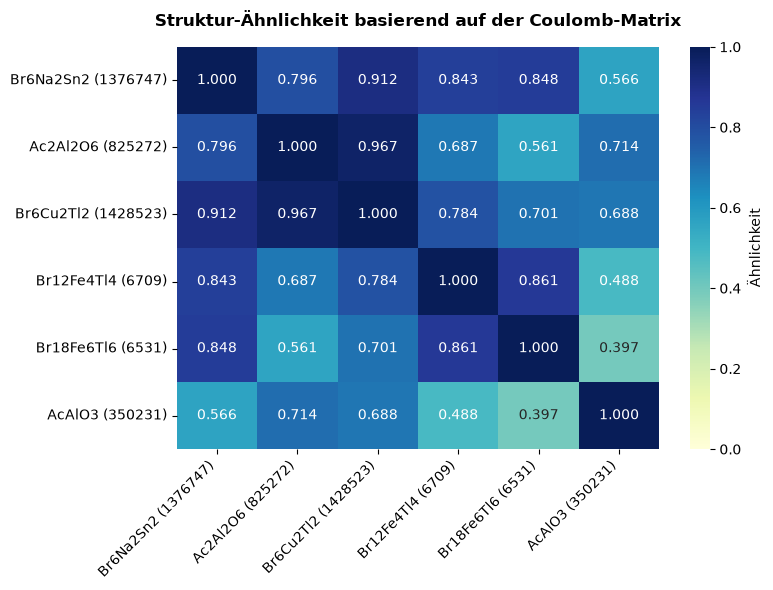

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Die berechneten Vektoren und IDs in Matrizen-Form bringen
ids_liste = list(coulomb_vektoren.keys())
formeln_liste = [f"{geladene_strukturen[idx].get_chemical_formula()} ({idx})" for idx in ids_liste]
vektoren_matrix = np.array([coulomb_vektoren[idx] for idx in ids_liste])

# 2. Kosinus-Ähnlichkeit berechnen
# Vergleicht jeden Vektor mit jedem anderen Vektor (ergibt eine 5x5 Matrix)
similarity_matrix = cosine_similarity(vektoren_matrix)

# 3. Als übersichtlichen Pandas DataFrame für die Textausgabe anzeigen
df_sim = pd.DataFrame(similarity_matrix, index=formeln_liste, columns=formeln_liste)

# 4. OPTIONAL: Das Ganze visuell als schöne Heatmap plotten
plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", cbar_kws={'label': 'Ähnlichkeit'})
plt.title("Struktur-Ähnlichkeit basierend auf der Coulomb-Matrix", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Extra Dataset for Coulomb matrices

In [17]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from dscribe.descriptors import CoulombMatrix
from scripts.structures2 import load_by_entry_id

def generate_coulomb_matrices_fast(max_allowed_atoms=30):
    # 1. IDs aus der CSV einlesen
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/data/oqmd_abx3_data.csv"
    df_csv = pd.read_csv(csv_path)
    id_list = df_csv.iloc[:, 1].dropna().astype(int).tolist()

    print(f"=== STARTE OPTIMIERTE COULOMB-MATRIX BERECHNUNG ===")
    print(f"Gesamtzahl IDs in CSV: {len(id_list)}")
    print(f"Maximale erlaubte Atomanzahl festgesetzt auf: {max_allowed_atoms}")
    print(f"Größere Strukturen werden automatisch übersprungen.\n")

    # 2. Coulomb-Matrix-Generator direkt konfigurieren
    # Da wir max_atoms auf max_allowed_atoms (30) deckeln, wissen wir die Größe vorab!
    # Das spart den kompletten ersten Durchlauf.
    cm_generator = CoulombMatrix(
        n_atoms_max=max_allowed_atoms,
        permutation="sorted_l2",
        sparse=False
    )

    cm_vectors_list = []
    skipped_too_large = 0
    missing_count = 0
    processed_count = 0

    print("Berechne Coulomb-Matrizen (Single-Pass-Verfahren)...")
    
    # Hauptschleife: Laden und direkt Berechnen in einem Rutsch
    for i, idx in enumerate(id_list):
        try:
            atoms = load_by_entry_id(idx)
            if not atoms:
                missing_count += 1
                continue
            
            # Überprüfen, ob die Struktur zu groß ist
            num_atoms = len(atoms)
            if num_atoms > max_allowed_atoms:
                skipped_too_large += 1
                continue

            # Direkt berechnen und merken
            cm_vector = cm_generator.create(atoms)
            cm_vectors_list.append(cm_vector)
            processed_count += 1

        except (KeyError, FileNotFoundError):
            missing_count += 1
            continue
        except Exception as e:
            print(f"Fehler bei ID {idx}: {e}")
            continue

        # Schnelles und kontinuierliches Fortschritts-Update im Terminal
        if (i + 1) % 200 == 0:
            print(f"-> Index {i + 1}/{len(id_list)} untersucht... (Erfolgreich berechnet: {processed_count} | Übersprungen da > {max_allowed_atoms} Atome: {skipped_too_large})")

    print("\n=== BERECHNUNG ABGESCHLOSSEN ===")
    print(f"Erfolgreich verarbeitete Strukturen: {processed_count}")
    print(f"Übersprungen (zu viele Atome > {max_allowed_atoms}): {skipped_too_large}")
    print(f"Nicht im Cache gefunden (missing): {missing_count}")

    # 3. Als hocheffiziente Numpy-Matrix speichern
    if len(cm_vectors_list) == 0:
        print("❌ Keine Strukturen erfolgreich verarbeitet. Datei wird nicht gespeichert.")
        return

    cm_matrix = np.array(cm_vectors_list)
    output_filename = "perovskite_coulomb_features.npy"
    np.save(output_filename, cm_matrix)
    
    print(f"\n✓ Coulomb-Feature-Matrix erfolgreich gespeichert!")
    print(f"-> Datei: {output_filename}")
    print(f"-> Matrix-Form (Shape): {cm_matrix.shape}")
    # Bei max 30 Atomen ist die Vektorlänge immer exakt 30 * 30 = 900 Features!

In [18]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from dscribe.descriptors import CoulombMatrix
from scripts.structures2 import load_by_entry_id

# 1. Die bereinigte Elementliste definieren (keine seltenen Erden / Radioaktiven)
clean_species_list = [
    "Ag", "Al", "As", "Au", "B", "Ba", "Be", "Bi", "Br", "C", "Ca", "Cd", "Cl", 
    "Co", "Cr", "Cs", "Cu", "F", "Fe", "Ga", "Ge", "H", "Hf", "Hg", "I", "In", 
    "Ir", "K", "Mg", "Mn", "Mo", "N", "Na", "Nb", "Ni", "O", "Os", "P", "Pb", 
    "Pd", "Pt", "Rb", "Re", "Rh", "Ru", "S", "Sb", "Sc", "Se", "Si", "Sn", "Sr", 
    "Ta", "Ti", "Tl", "V", "W", "Y", "Zn", "Zr"
]

def create_CoulombM_dataset(clean_species_list, max_atoms_limit=30):
    """
    Filtert den Datensatz nach erlaubten Elementen UND maximaler Atomanzahl (<= 30).
    Berechnet parallel wahlweise Coulomb-Matrizen oder SOAP-Features.
    """
    clean_species_set = set(clean_species_list)
    
    descriptor_generator = CoulombMatrix(
            n_atoms_max=max_atoms_limit,
            permutation="sorted_l2",
            sparse=False
        )

    # 2. Original-CSV laden
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview.csv"
    df_original = pd.read_csv(csv_path)

    print(f"Originaler Datensatz enthält {len(df_original)} Zeilen.")
    print(f"Starte Filterung: Erlaubte Elemente & Atomanzahl <= {max_atoms_limit}...")

    filtered_rows = []
    features_list = []
    missing_count = 0
    skipped_too_large = 0
    skipped_wrong_elements = 0

    # Schleife über den DataFrame
    for i, row in df_original.iterrows():
        # Die entry_id steht in der ersten Spalte (Spaltenindex 0)
        entry_id = int(row.iloc[0])
        
        try:
            atoms = load_by_entry_id(entry_id)
            if atoms:
                # BEDINGUNG 1: Atomanzahl prüfen (maximal 30 Atome)
                if len(atoms) > max_atoms_limit:
                    skipped_too_large += 1
                    continue
                
                # BEDINGUNG 2: Chemische Elemente prüfen
                structure_elements = set(atoms.get_chemical_symbols())
                if structure_elements.issubset(clean_species_set):
                    # Struktur erfüllt alle Kriterien -> Speichern
                    filtered_rows.append(row)
                
                    # Feature-Vektor berechnen (falls gewünscht)
                
                    feature_vector = descriptor_generator.create(atoms)
                    features_list.append(feature_vector)
                else:
                    skipped_wrong_elements += 1
                    
        except (KeyError, FileNotFoundError):
            missing_count += 1
            continue

        # Fortschritts-Update
        if (i + 1) % 1000 == 0:
            print(f"-> {i + 1} / {len(df_original)} Strukturen überprüft. Aktuell {len(filtered_rows)} Treffer...")

    print("\n=== FILTERUNG BEENDET ===")
    print(f"Nicht im Cache gefundene IDs: {missing_count}")
    print(f"Übersprungen, da > {max_atoms_limit} Atome: {skipped_too_large}")
    print(f"Übersprungen wegen nicht erlaubten Elementen: {skipped_wrong_elements}")

    # 3. Neuen DataFrame erstellen und als CSV speichern
    df_filtered = pd.DataFrame(filtered_rows)
    print(f"Neuer gefilterter Datensatz enthält {len(df_filtered)} Strukturen.")

    output_csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced_CoulombM.csv"
    df_filtered.to_csv(output_csv_path, index=False)
    print(f"✓ Erfolgreich neues Dataset gespeichert unter: {output_csv_path}")

  
    features_matrix = np.array(features_list)
        
    output_npy_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_coulomb_features_reduced.npy"
            
    np.save(output_npy_path, features_matrix)
    print(f"Feature-Matrix gespeichert. Form: {features_matrix.shape}")


create_CoulombM_dataset(clean_species_list, max_atoms_limit=30)

Originaler Datensatz enthält 16316 Zeilen.
Starte Filterung: Erlaubte Elemente & Atomanzahl <= 30...
-> 1000 / 16316 Strukturen überprüft. Aktuell 745 Treffer...
-> 2000 / 16316 Strukturen überprüft. Aktuell 1245 Treffer...
-> 3000 / 16316 Strukturen überprüft. Aktuell 2005 Treffer...
-> 4000 / 16316 Strukturen überprüft. Aktuell 2541 Treffer...
-> 5000 / 16316 Strukturen überprüft. Aktuell 2928 Treffer...
-> 6000 / 16316 Strukturen überprüft. Aktuell 3208 Treffer...
-> 7000 / 16316 Strukturen überprüft. Aktuell 3817 Treffer...
-> 8000 / 16316 Strukturen überprüft. Aktuell 3976 Treffer...
-> 9000 / 16316 Strukturen überprüft. Aktuell 4539 Treffer...
-> 10000 / 16316 Strukturen überprüft. Aktuell 5065 Treffer...
-> 11000 / 16316 Strukturen überprüft. Aktuell 5129 Treffer...
-> 12000 / 16316 Strukturen überprüft. Aktuell 5615 Treffer...
-> 13000 / 16316 Strukturen überprüft. Aktuell 6198 Treffer...
-> 14000 / 16316 Strukturen überprüft. Aktuell 6610 Treffer...
-> 15000 / 16316 Strukturen

# ==================================================

## Erweiterung: Ewald Sum Matrix

In [21]:
import numpy as np
import pandas as pd
from dscribe.descriptors import EwaldSumMatrix
from scripts.structures2 import load_by_entry_id

# 1. Definiere 5 Beispiel-IDs (Ersetze diese mit IDs aus deinem Datensatz)
beispiel_ids = [1376747, 825272, 1428523, 6709, 6531,350231]

# 2. Strukturen vorab laden und die maximale Atomanzahl bestimmen
geladene_strukturen = {}
max_atoms = 0

print("Lade Strukturen und ermittle maximale Atomanzahl...")
for idx in beispiel_ids:
    atoms = load_by_entry_id(idx)
    if atoms is not None:
        geladene_strukturen[idx] = atoms
        print(f"-> ID {idx} geladen: {atoms.get_chemical_formula()} ({len(atoms)} Atome)")
        if len(atoms) > max_atoms:
            max_atoms = len(atoms)
    else:
        print(f"❌ ID {idx} konnte nicht geladen werden.")

# 3. Den Coulomb-Matrix-Generator mit der maximalen Atomanzahl konfigurieren
# flatten=True ist standardmäßig aktiv, wenn man es nicht explizit ausschaltet.
em_ml_generator = EwaldSumMatrix(
    n_atoms_max=max_atoms,
    permutation="sorted_l2",  # Wichtig für den Strukturvergleich
    sparse=False
)

# 4. Coulomb-Vektoren berechnen und in einem Dictionary speichern
ewald_vektoren = {}
for idx, atoms in geladene_strukturen.items():
    ewald_vektoren[idx] = em_ml_generator.create(atoms)

print(f"\n✓ Coulomb-Vektoren für {len(ewald_vektoren)} Strukturen berechnet.")
print(f"Jeder Vektor hat eine einheitliche Länge von: {max_atoms * max_atoms} Features.")

Lade Strukturen und ermittle maximale Atomanzahl...
-> ID 1376747 geladen: Br6Na2Sn2 (10 Atome)
-> ID 825272 geladen: Ac2Al2O6 (10 Atome)
-> ID 1428523 geladen: Br6Cu2Tl2 (10 Atome)
-> ID 6709 geladen: Br12Fe4Tl4 (20 Atome)
-> ID 6531 geladen: Br18Fe6Tl6 (30 Atome)
-> ID 350231 geladen: AcAlO3 (5 Atome)

✓ Coulomb-Vektoren für 6 Strukturen berechnet.
Jeder Vektor hat eine einheitliche Länge von: 900 Features.


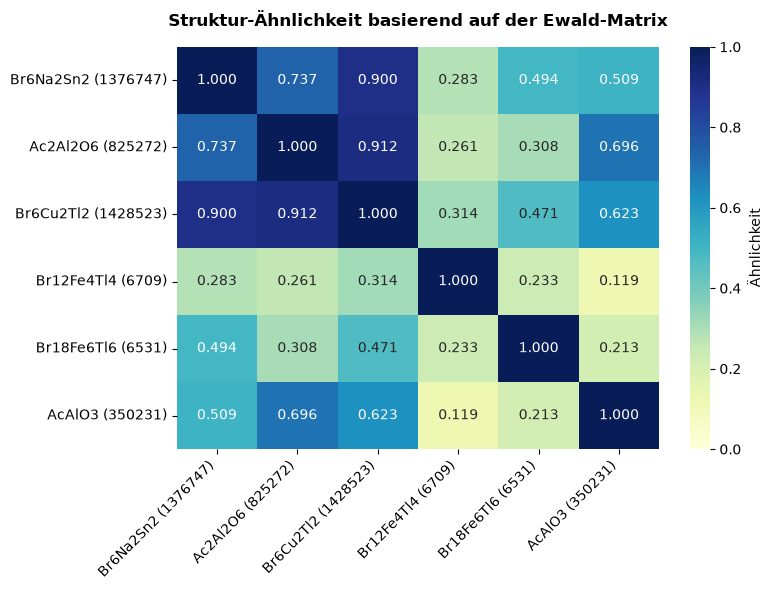

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Die berechneten Vektoren und IDs in Matrizen-Form bringen
ids_liste = list(ewald_vektoren.keys())
formeln_liste = [f"{geladene_strukturen[idx].get_chemical_formula()} ({idx})" for idx in ids_liste]
vektoren_matrix = np.array([ewald_vektoren[idx] for idx in ids_liste])

# 2. Kosinus-Ähnlichkeit berechnen
# Vergleicht jeden Vektor mit jedem anderen Vektor (ergibt eine 5x5 Matrix)
similarity_matrix = cosine_similarity(vektoren_matrix)

# 3. Als übersichtlichen Pandas DataFrame für die Textausgabe anzeigen
df_sim = pd.DataFrame(similarity_matrix, index=formeln_liste, columns=formeln_liste)

# 4. OPTIONAL: Das Ganze visuell als schöne Heatmap plotten
plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", cbar_kws={'label': 'Ähnlichkeit'})
plt.title("Struktur-Ähnlichkeit basierend auf der Ewald-Matrix", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Extra Dataset für Ewald-Sum-Matrizen

In [24]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from dscribe.descriptors import EwaldSumMatrix
from scripts.structures2 import load_by_entry_id

# 1. Die bereinigte Elementliste definieren (keine seltenen Erden / Radioaktiven)
clean_species_list = [
    "Ag", "Al", "As", "Au", "B", "Ba", "Be", "Bi", "Br", "C", "Ca", "Cd", "Cl", 
    "Co", "Cr", "Cs", "Cu", "F", "Fe", "Ga", "Ge", "H", "Hf", "Hg", "I", "In", 
    "Ir", "K", "Mg", "Mn", "Mo", "N", "Na", "Nb", "Ni", "O", "Os", "P", "Pb", 
    "Pd", "Pt", "Rb", "Re", "Rh", "Ru", "S", "Sb", "Sc", "Se", "Si", "Sn", "Sr", 
    "Ta", "Ti", "Tl", "V", "W", "Y", "Zn", "Zr"
]

def create_EwaldM_dataset(clean_species_list, max_atoms_limit=30):
    """
    Filtert den Datensatz nach erlaubten Elementen UND maximaler Atomanzahl (<= 30).
    Berechnet parallel wahlweise Coulomb-Matrizen oder SOAP-Features.
    """
    clean_species_set = set(clean_species_list)
    
    descriptor_generator = EwaldSumMatrix(
            n_atoms_max=max_atoms_limit,
            permutation="sorted_l2",
            sparse=False
        )

    # 2. Original-CSV laden
    csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview.csv"
    df_original = pd.read_csv(csv_path)

    print(f"Originaler Datensatz enthält {len(df_original)} Zeilen.")
    print(f"Starte Filterung: Erlaubte Elemente & Atomanzahl <= {max_atoms_limit}...")

    filtered_rows = []
    features_list = []
    missing_count = 0
    skipped_too_large = 0
    skipped_wrong_elements = 0

    # Schleife über den DataFrame
    for i, row in df_original.iterrows():
        # Die entry_id steht in der ersten Spalte (Spaltenindex 0)
        entry_id = int(row.iloc[0])
        
        try:
            atoms = load_by_entry_id(entry_id)
            if atoms:
                # BEDINGUNG 1: Atomanzahl prüfen (maximal 30 Atome)
                if len(atoms) > max_atoms_limit:
                    skipped_too_large += 1
                    continue
                
                # BEDINGUNG 2: Chemische Elemente prüfen
                structure_elements = set(atoms.get_chemical_symbols())
                if structure_elements.issubset(clean_species_set):
                    # Struktur erfüllt alle Kriterien -> Speichern
                    filtered_rows.append(row)
                
                    # Feature-Vektor berechnen (falls gewünscht)
                
                    feature_vector = descriptor_generator.create(atoms)
                    features_list.append(feature_vector)
                else:
                    skipped_wrong_elements += 1
                    
        except (KeyError, FileNotFoundError):
            missing_count += 1
            continue

        # Fortschritts-Update
        if (i + 1) % 1000 == 0:
            print(f"-> {i + 1} / {len(df_original)} Strukturen überprüft. Aktuell {len(filtered_rows)} Treffer...")

    print("\n=== FILTERUNG BEENDET ===")
    print(f"Nicht im Cache gefundene IDs: {missing_count}")
    print(f"Übersprungen, da > {max_atoms_limit} Atome: {skipped_too_large}")
    print(f"Übersprungen wegen nicht erlaubten Elementen: {skipped_wrong_elements}")

    # 3. Neuen DataFrame erstellen und als CSV speichern
    df_filtered = pd.DataFrame(filtered_rows)
    print(f"Neuer gefilterter Datensatz enthält {len(df_filtered)} Strukturen.")

    output_csv_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_metadata_overview_reduced_EwaldM.csv"
    df_filtered.to_csv(output_csv_path, index=False)
    print(f"✓ Erfolgreich neues Dataset gespeichert unter: {output_csv_path}")

  
    features_matrix = np.array(features_list)
        
    output_npy_path = "/Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project/perovskite_ewald_features_reduced.npy"
            
    np.save(output_npy_path, features_matrix)
    print(f"Feature-Matrix gespeichert. Form: {features_matrix.shape}")


create_EwaldM_dataset(clean_species_list, max_atoms_limit=30)

Originaler Datensatz enthält 16316 Zeilen.
Starte Filterung: Erlaubte Elemente & Atomanzahl <= 30...
-> 1000 / 16316 Strukturen überprüft. Aktuell 745 Treffer...
-> 2000 / 16316 Strukturen überprüft. Aktuell 1245 Treffer...
-> 3000 / 16316 Strukturen überprüft. Aktuell 2005 Treffer...
-> 4000 / 16316 Strukturen überprüft. Aktuell 2541 Treffer...
-> 5000 / 16316 Strukturen überprüft. Aktuell 2928 Treffer...
-> 6000 / 16316 Strukturen überprüft. Aktuell 3208 Treffer...
-> 7000 / 16316 Strukturen überprüft. Aktuell 3817 Treffer...
-> 8000 / 16316 Strukturen überprüft. Aktuell 3976 Treffer...
-> 9000 / 16316 Strukturen überprüft. Aktuell 4539 Treffer...
-> 10000 / 16316 Strukturen überprüft. Aktuell 5065 Treffer...
-> 11000 / 16316 Strukturen überprüft. Aktuell 5129 Treffer...
-> 12000 / 16316 Strukturen überprüft. Aktuell 5615 Treffer...
-> 13000 / 16316 Strukturen überprüft. Aktuell 6198 Treffer...
-> 14000 / 16316 Strukturen überprüft. Aktuell 6610 Treffer...
-> 15000 / 16316 Strukturen